A1. Data Wrangling

In [1]:
import pandas as pd

1.

In [ ]:
df = pd.read_csv('data/Student_List_A2.csv')
print(df.columns)

2.

In [3]:
df['GradeClass'] = df['GradeClass'].replace({'A':0, 'B':1, 'C':2, 'D':3,'F':4})
print(df['GradeClass'].unique())

[1 4 3 2 0]


In [4]:
df['StudyTimeWeekly'].describe()

count    2079.000000
mean        9.676082
std         5.667623
min         0.004859
25%         4.895155
50%         9.513101
75%        14.324899
max        19.978094
Name: StudyTimeWeekly, dtype: float64

In [5]:
#First seeing how many value is there in each columns
for col in df.columns:
    print(col, len(df[col]))

StudentID 2100
Age 2100
StudyTimeWeekly 2100
Absences 2100
ParentalSupport 2100
GPA 2100
GradeClass 2100


In [6]:
#Seeing how many value each columns actually not null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   StudentID        2100 non-null   int64  
 1   Age              2100 non-null   int64  
 2   StudyTimeWeekly  2079 non-null   float64
 3   Absences         2100 non-null   int64  
 4   ParentalSupport  2100 non-null   int64  
 5   GPA              2100 non-null   float64
 6   GradeClass       2100 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 115.0 KB


Notice that in StudyTimeWeekly just only 2079 compared the length of value 2100, mission 21 values.

In [7]:
df.isnull().sum()

StudentID           0
Age                 0
StudyTimeWeekly    21
Absences            0
ParentalSupport     0
GPA                 0
GradeClass          0
dtype: int64

In [8]:
df.fillna(df.StudyTimeWeekly.median(), inplace=True)

In [9]:
df.isnull().sum()

StudentID          0
Age                0
StudyTimeWeekly    0
Absences           0
ParentalSupport    0
GPA                0
GradeClass         0
dtype: int64

In [10]:
df['Absences'].describe()

count    2100.000000
mean       14.709048
std        11.153253
min      -122.000000
25%         7.000000
50%        15.000000
75%        22.000000
max       320.000000
Name: Absences, dtype: float64

In [11]:
invalid_value = (df["Absences"] < 0) | (df['Absences'] > 365)
df[invalid_value]

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
1001,2003,15,0.806505,-122,3,3.20171,1


In [12]:
df = df.loc[~invalid_value]

In [13]:
df['Absences'].describe()

count    2099.000000
mean       14.774178
std        10.749043
min         0.000000
25%         7.000000
50%        15.000000
75%        22.000000
max       320.000000
Name: Absences, dtype: float64

This is called the regularities because its faulty of data entry. This always happens when we enter data in real life, pressing the minus sign by mistake or formating issue.

In [14]:
df["Grade_from_GPA"] = 4
df.loc[df.GPA >= 2.0, "Grade_from_GPA"] = 3
df.loc[df.GPA >= 2.5, "Grade_from_GPA"] = 2
df.loc[df.GPA >= 3.0, "Grade_from_GPA"] = 1
df.loc[df.GPA >= 3.5, "Grade_from_GPA"] = 0

In [15]:
mislabelled_students = df["GradeClass"] != df["Grade_from_GPA"]
print("Mislabelled students:", mislabelled_students.sum())
print("Example StudentIDs:", df.loc[mislabelled_students, "StudentID"].head(10).tolist())
df[mislabelled_students].head(10)

Mislabelled students: 100
Example StudentIDs: [3182, 3183, 3189, 3193, 3195, 3199, 3202, 3206, 3208, 3210]


,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass,Grade_from_GPA
2000,3182,15,3.253044,13,1,1.844056,1,4
2001,3183,17,17.086920,25,2,1.305585,2,4
2002,3189,16,5.697054,9,1,2.459805,1,3
2003,3193,16,15.827054,28,1,0.818126,2,4
2004,3195,15,15.615710,26,3,1.174610,0,4
2005,3199,16,1.511090,3,3,2.732661,0,2
2006,3202,16,8.188959,15,3,2.060792,2,3
2007,3206,15,6.013113,22,3,1.028184,1,4
2008,3208,18,7.518768,17,3,1.672034,1,4
2009,3210,15,17.531962,24,2,0.859745,1,4


I trust the GPA since the GPA is a continuous numeric measure with actual thresholds. And the GradClass is a label depended from that, and more prone to misspelling and inconsistency.

In [16]:
df.loc[mislabelled_students, "GradeClass"] = df.loc[mislabelled_students, "Grade_from_GPA"]

mislabelled_students = df["GradeClass"] != df["Grade_from_GPA"]
print("Mislabelled students:", mislabelled_students.sum())
df.drop(columns =['Grade_from_GPA'], inplace= True)
df

Mislabelled students: 0


,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
0,1002,18,15.408756,0,1,3.042915,1
1,1003,15,4.210570,26,2,0.112602,4
2,1004,17,10.028829,14,3,2.054218,3
3,1005,17,4.672495,17,3,1.288061,4
4,1006,18,8.191219,0,1,3.084184,1
...,...,...,...,...,...,...,...
2095,3386,16,1.445434,20,3,1.395631,4
2096,3388,18,10.680555,2,4,3.455509,1
2097,3390,16,6.805500,20,2,1.142333,4
2098,3391,16,12.416653,17,2,1.803297,4


A2. Data Exploration and Visualisation

In [17]:
total = len(df["GradeClass"])
percentage_class_0 = round(len(df[df['GradeClass'] == 0]) / total * 100, 1)
percentage_class_1 = round(len(df[df['GradeClass'] == 1]) / total * 100, 1)
percentage_class_2 = round(len(df[df['GradeClass'] == 2]) / total * 100, 1)
percentage_class_3 = round(len(df[df['GradeClass'] == 3]) / total * 100, 1)
percentage_class_4 = round(len(df[df['GradeClass'] == 4]) / total * 100, 1)

print(percentage_class_0)
print(percentage_class_1)
print(percentage_class_2)
print(percentage_class_3)
print(percentage_class_4)

2.9
9.7
16.2
17.6
53.6


In [18]:
fun = {'StudentID':'count'}
groupbyClass = df.groupby('GradeClass').agg(fun)
groupbyClass.rename(columns = {'StudentID':'Student count'},inplace = True)
groupbyClass

,Student count
GradeClass,
0,61
1,204
2,339
3,369
4,1126


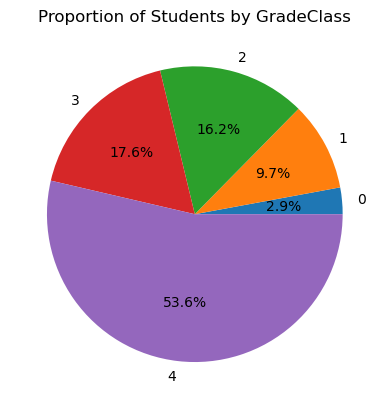

In [19]:
import matplotlib.pylab as plt
%matplotlib inline
order = [0,1,2,3,4]
plt.pie(groupbyClass['Student count'], labels=order, autopct='%1.1f%%')
plt.title("Proportion of Students by GradeClass")
plt.show()

My observations are the most of the students are in GradeClass 4, and the students are in GradeClass 0 is the smallest. The number of student in GradeClass 3 and 2 are relatively the same. The number of students in GradeClass 4 is triple than the number of students in GradeClass 3 or 2.

The percentage of each GradeClass in the pie chart is the same as the calculation in the A2.1 I do.

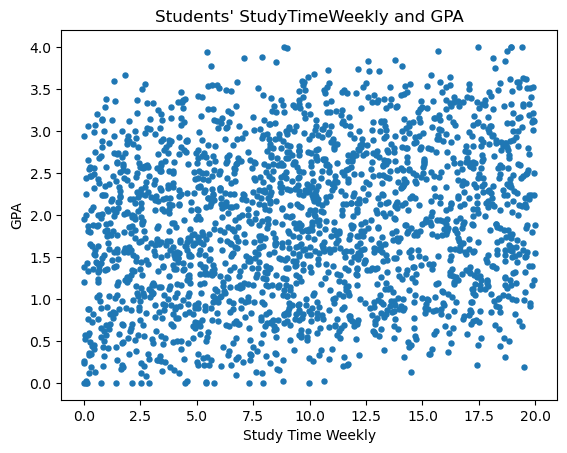

In [20]:
plt.scatter(df["StudyTimeWeekly"], df["GPA"], s=13)
plt.xlabel("Study Time Weekly")
plt.ylabel("GPA")
plt.title("Students' StudyTimeWeekly and GPA")
plt.show()

In [21]:
corr = df[["StudyTimeWeekly","GPA"]].corr()
print(corr)

                 StudyTimeWeekly       GPA
StudyTimeWeekly         1.000000  0.179008
GPA                     0.179008  1.000000


In [22]:
print("Correlation (StudyTimeWeekly, GPA):", round(corr.loc["StudyTimeWeekly","GPA"], 3))

Correlation (StudyTimeWeekly, GPA): 0.179


This is a slight positive trend, meaning students who study more tend to get a bit higher GPA.

5.

In [23]:
corr2 = df[["Absences","GPA"]].corr()
print(corr2)

          Absences       GPA
Absences  1.000000 -0.721176
GPA      -0.721176  1.000000


In [24]:
print("Correlation (Absences, GPA):", round(corr2.loc["Absences","GPA"], 3))

Correlation (Absences, GPA): -0.721


This is a strong negative trend, meaning students with more absences engage less and or miss assesstments, so their GPA is substantially lower.

6.

The answer is no, this is because correlation can be driven by the confounder like how difficulty the subject is or how the teaching is, other factors like incorrect values of the data, since they can be a measurement error like students self reported the time they study so its not a strong foundation, or some students 

The additional data could strength the argument is:
 - Richer confounders: like previous students GPA, standarlized test scores, course load, teacher ability, sleep or health of the student, any part-time job of the student and how many hours they doing, how they parents support by letting them going to cram school or hire a tutor.
 - Better measurements: time-use logs for study time, using tools exactly to count time not just self-reported.

In [25]:
fun2 = {"GPA": ["mean", "median", "std",(lambda x: x.quantile(0.75) - x.quantile(0.25))],
    "Absences": ["mean", "median", "std",(lambda x: x.quantile(0.75) - x.quantile(0.25))]}
groupClass2 = df.groupby("GradeClass").agg(fun2)
groupClass2

GPA                                  Absences         \
                mean    median       std <lambda_0>       mean median   
GradeClass                                                              
0           3.681490  3.618273  0.163589   0.275281   1.475410    1.0   
1           3.227285  3.219432  0.143109   0.242832   3.308824    3.0   
2           2.732964  2.723828  0.145818   0.250655   6.433628    6.0   
3           2.249837  2.240924  0.137388   0.230745  11.140921   11.0   
4           1.182168  1.234493  0.513638   0.787667  21.273535   21.0   

                                  
                  std <lambda_0>  
GradeClass                        
0            1.659383        3.0  
1            2.500782        4.0  
2            3.562318        5.0  
3            3.783787        6.0  
4           10.232486        8.0

In [26]:
groupClass2.rename(columns ={"mean":"GPA_mean", "median":"GPA_median}", "std":"GPA_std", "<lambda_0>":"GPA_IQR", 
                    "mean":"Absences_mean","median":"Absences_median", "std":"Absences_std", "<lambda_0>":"Absences_IQR"}, inplace=True)
groupClass2 = groupClass2.reset_index()
groupClass2

GradeClass           GPA                                            \
             Absences_mean Absences_median Absences_std Absences_IQR   
0          0      3.681490        3.618273     0.163589     0.275281   
1          1      3.227285        3.219432     0.143109     0.242832   
2          2      2.732964        2.723828     0.145818     0.250655   
3          3      2.249837        2.240924     0.137388     0.230745   
4          4      1.182168        1.234493     0.513638     0.787667   

       Absences                                            
  Absences_mean Absences_median Absences_std Absences_IQR  
0      1.475410             1.0     1.659383          3.0  
1      3.308824             3.0     2.500782          4.0  
2      6.433628             6.0     3.562318          5.0  
3     11.140921            11.0     3.783787          6.0  
4     21.273535            21.0    10.232486          8.0

A3. Supervised Learning

Supervised ML with the GradeClass as the label means training the classifier to map the feature or some kind of inputs into the machine to a specific label like 0,1,2,.. The model learns from the labelled examples and then try to preicts the label for new students as new inputs.
Training set is what the model use to study, labelled examples uses to adjust and find a rules behind the numbers. Whereas, the test set is a separate, unseen portion used only to evaluate how well the model algorithm learned rules and generalises to new cases. 
The risk if not holding out a test set is that you get a overly optimistic performance because the model may fit exactly in the trainning data without noise, this called overfitting, so it looks good in the given set but fails on the new students, this is why evaluation on unseen test data is emphasised.

StudentID: Exclude
 -Identifier? Yes.
 -Overlap with label? No.
 -Useful? No, IDs don’t describe behaviour.

Age: Keep
- Identifier? No.
- Overlap with label? No.
- Useful? It might be a plausible signal since maturity can relate to outcomes.

StudyTimeWeekly: Keep
- Identifier? No.
- Overlap with label? No.
- Useful? Yes, its direct effort proxy, we've observed a small positive correlation with GPA/grades.

Absences: Keep
- Identifier? No.
- Overlap with label? No.
- Useful? Yes, strong negative relationship with performance, more absences result in lower achievement, this we have show in the A2.

ParentalSupport: Keep
- Identifier? No.
- Overlap with label? No.
- Useful? Yes, it might be the case that environmental support can influence study behaviour and results.

GPA: Exclude
- Identifier? No.
- Overlap with label? Yes, GradeClass is defined by GPA cut-offs.

GradeClass: its the Label
- This is the target you’re predicting, so its not a feature.

In [27]:
y = df["GradeClass"]
x = df[["Age", "StudyTimeWeekly", "Absences", "ParentalSupport"]].copy()


In [28]:
from sklearn.model_selection import train_test_split

# the stratify will make the split more fair.
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.70, test_size=0.30, random_state=0, stratify=y) 

print("Total:", len(df))
print("Train:", len(x_train))
print("Test :", len(x_test))

Total: 2099
Train: 1469
Test : 630


If I had a very small dataset, I wouldnt use 70/30 since it would be too little trainning data that underfit the model, and too few test sample to test accuracy.

A4. Classification

a. Since raw features can have very different ranges, many ML algorithms that use distances or dot products like k-means or linear regression can behave poorly without scaling. If features are different scales, the biggest range feature dominates the computations, so the model pay attention mostly to that feature. Normalising puts features on comparable scales so each contributes fairly and training is numerically stable, and makes visualisations of the feature space meaningful.

Typical ranges of Age is 15-18 years, whereas Absences is 0-320 days. Compare 2 students who differ by 3 years of Age and 30 days of Absences. Unscaled Euclidean distance is (roots of (3^2 + 30^2)) = 30.1. The distance is approximately 99% from Absences, so a distance based classifier will mostly ignore Age feature. After standardisation, the differences are measured in standard deviations. A 3-year Age gap might be around 1 SD, while 30 Absences could be 1 SD so the margin isnt warped by units.

In [29]:
import numpy as np
# two students differ by 4 years of age and 40 days of absences
age_difference, abs_difference = 3, 30
raw_distance = np.sqrt(age_difference**2 + abs_difference**2)  # ≈ 40.2
print("Raw Euclidean distance:", raw_distance)

# After standardisation 1 like SD ≈ 3 years, 1 SD ≈ 10 days
age_scaled, abs_scaled = age_difference/3, abs_difference/10
scaled_dist = np.sqrt(age_scaled**2 + abs_scaled**2)    
print("Scaled Euclidean distance:", round(scaled_dist, 2))

Raw Euclidean distance: 30.14962686336267
Scaled Euclidean distance: 3.16


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns, index=x_train.index)
x_test_scaled  = pd.DataFrame(x_test_scaled,  columns=x_test.columns,  index=x_test.index)

print("x_train columns:\n", x_train)
print("x_train_scaled columns:\n", x_train_scaled) #All columns were scaled.

x_train columns:
       Age  StudyTimeWeekly  Absences  ParentalSupport
1289   15         8.735543        17                1
1208   15         9.830285        23                1
1579   18         4.609897        26                3
1214   15         1.792635         5                1
1976   17         9.921510         4                1
...   ...              ...       ...              ...
2078   17        18.782174        19                2
1703   17        11.702433         7                2
1773   17         5.490892         8                3
1666   15        17.525847        13                3
200    18         8.055711        18                1

[1469 rows x 4 columns]
x_train_scaled columns:
            Age  StudyTimeWeekly  Absences  ParentalSupport
1289 -1.315003        -0.167071  0.181120        -1.011555
1208 -1.315003         0.025768  0.698925        -1.011555
1579  1.365486        -0.893803  0.957827         0.776621
1214 -1.315003        -1.390064 -0.854490       

2.

a. the goal of SVM is a classifier to find the optimal seperating hyperplane with the largest margin between data points to the closest points by the support vectors to have a better generalizaion.

b. kernel is like a mathematical function that enables the algorithm to implicity map data into higher-dimensional feature space without really computing the coordinates in that space.

In [31]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(x_train_scaled, y_train)

SVC()

In [32]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=0, max_depth=8)
dt.fit(x_train_scaled, y_train)

DecisionTreeClassifier(max_depth=8, random_state=0)

A5. Classification

In [33]:
y_pred_svm = svc.predict(x_test_scaled)
y_pred_dt = dt.predict(x_test_scaled)

In [34]:
from sklearn.metrics import confusion_matrix

cm_svm   = confusion_matrix(y_test,  y_pred_svm,   labels=order)
cm_dt = confusion_matrix(y_test,  y_pred_dt, labels=order)

print("SVM - Confusion Matrix:")
print(pd.DataFrame(cm_svm,   index=order, columns=order))
print("DT - Confusion Matrix:")
print(pd.DataFrame(cm_dt, index=order, columns=order))

SVM - Confusion Matrix:
   0   1   2   3    4
0  0  16   2   0    0
1  0  33  28   0    0
2  0  14  62  23    3
3  0   0  28  61   22
4  0   0   4  17  317
DT - Confusion Matrix:
   0   1   2   3    4
0  7  10   1   0    0
1  6  39  13   3    0
2  1  26  40  30    5
3  0   0  30  52   29
4  0   0   4  22  312


The fequent confusion happening in both model is 2 ↔ 3 (C ↔ D) confusion, this is because the overlapping behaviour, the students may be the same with roughly same absences, StudyTimeWeekly, PartentalSupport or Age, this similar range are unobserved differences in GPA, which causing 2 ↔ 3 (C ↔ D) confusion.

So the accuracy for SVM: 0+33+62+61+317 = 453/630 = 0.75, whereas DT: 7+39+40+52+312 = 450/630 = 0.714, so SVM is  better. However, looking at the SVM model have a better accuracy for 2 3 4 since it is the majority, it ignore or completely wrong for the 0, while the DT model have more spread accuracy, got it right for 0 in 7 times. Overall, for majority of students SVM would perform better however if we fit many student class 0, SVM would be less accurate than DT.  

3.

In [35]:
print("SVM train:", svc.score(x_train_scaled, y_train))
print("SVM test:", svc.score(x_test_scaled,  y_test))

print("DT  train:", dt.score(x_train_scaled, y_train))
print("DT  test:", dt.score(x_test_scaled,  y_test))

SVM train: 0.7787610619469026
SVM test: 0.7507936507936508
DT  train: 0.8495575221238938
DT  test: 0.7142857142857143


Now looking at results for training and testing set, the score for training is more accurate, the gap and in the confusion matrix, SVM have more correctness in the majority, meaning it have high bias. There is also many false positives for 0 (1 -> 0), 2 ->1, 2 ->3,..., but the overall accuracy between the test and train is not too different, so it have a moderate variance.

The decision tree have maximum depth 8, which might be overfit for some classes. In the confusion matrix, it shows strong performance on 4, weaker on 0, 2, 3, meaning it have high bias. Looking at the training and testing results, it drops a lots, meaning it have high variance as well.

A6

In [ ]:
df3 = pd.read_csv("data/Student_List_A2_Submission.csv")
df3

In [37]:
ids = df3["StudentID"].copy()

x_test_submis = df3[["Age", "StudyTimeWeekly", "Absences", "ParentalSupport"]].copy()
x_test_submis_scaled = scaler.transform(x_test_submis)

pred_submis = svc.predict(x_test_submis_scaled)

out = pd.DataFrame({"StudentID": ids, "GradeClass": pred_submis})
out.to_csv("35697601-TuanNgocChu-v1.csv", index = False)

C:\Users\Ngoc\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


B. Selection of Dataset

1. I use this dataset from here: https://www.kaggle.com/datasets/ilayaraja07/data-cleaning-feature-imputation


2.

In [ ]:
df_b = pd.read_csv("data/Students_Performance_knn.csv")
df_b

In [39]:
df_b.isnull().sum()

gender                          0
race/ethnicity                  0
parental level of education     0
lunch                          25
test preparation course         0
math score                      0
reading score                   0
writing score                   0
dtype: int64

In [40]:
df_b.fillna(df_b.lunch.mode().iloc[0], inplace=True)
df_b.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

First I use isnull for all the features in df_b, and sum all the na that appear in that columns to see which columns contain how many na, I spot lunch column have 25 na then I fill na using the most frequent lunch category, since the mode return the series, so I need to choose the first item which is the most frequent one. Finnally, checking the na for each columns again and it is filled.

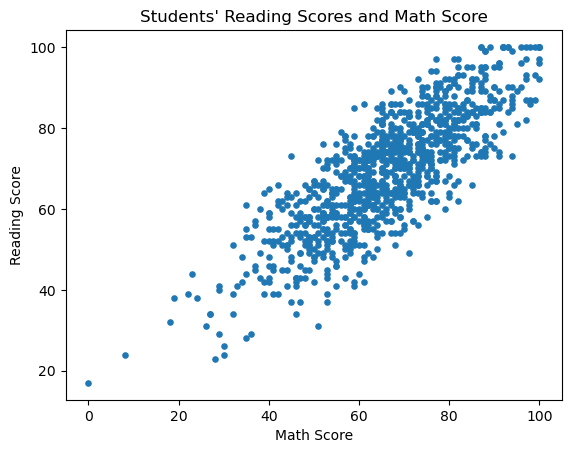

In [41]:
plt.scatter(x=df_b['math score'],y=df_b['reading score'], s=14)
plt.xlabel('Math Score')
plt.ylabel('Reading Score')
plt.title("Students' Reading Scores and Math Score")
plt.show()

 I choose k = 3 because, when I tried k =1 or 2, the cluster seems to larger doesnt have deep seperation that tell specific groups, when I choose k >3 and above, I saw that it just added extra clusters mostly just slices existing groups. When k =3, it show a compact, well-separated clusters.

5.

This dataset meets the description have missing values and have aleast 2 numerical features and its csv, which is easier to read and I'm more familiar with it. And k-means is appropriate since it use Euclidean distance to seperate clusters, this depend on numeric continuous features. So when I want to see what is the pattern the Students' Reading Scores and Math Score, what are they relationship, using the k-means to see is appropriate for the job, it will do seperated group well.

6.

When looking at the raw data visualasation, I see the seperated part in the trend so I would guess there would be 3 group of students, the middle group is the largest, the most compacted and the lower group would be spread, not high compacted, upper group is decent compacted, and not to spread. This is true when I do the k-means with k =3, result what I expected.